# Progetto DIA - A.A 2025/26

Autori: Justin Carideo (justin.carideo@studio.unibo.it), Laura Bertozzi (laura.bertozzi5@studio.unibo.it)

# Setup

## Caricamento librerie

* `NumPy` per creare e operare su array a n dimensioni
* `mathplotlib` e `seaborn` per creare grafici
* `pandas` per creare e manipolare dati tabulari
* `scikit-learn` per la gestione dei modelli di apprendimento
* `os` e `kaggle` per il download dei dataset


In [686]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import seaborn as sns
import kaggle
import os
import os.path

sns.set_theme(style="whitegrid")

In [687]:

# Librerie scikit-learn
from sklearn.model_selection import KFold, StratifiedKFold, RandomizedSearchCV
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, Perceptron

from xgboost import XGBClassifier


Importiamo i dataset presi dal sito https://www.kaggle.com. Questi due dataset fanno riferimento a dati in ambito agricolo, in particolare:
1) **Crop Dataset** -> dataset che presenta variabili legate a caratteristiche del terreno e dei nutrienti presenti, utili a dedurre quale sia la coltura ideale (https://www.kaggle.com/datasets/varshitanalluri/crop-recommendation-dataset)
2) **Fertilizer DataSet** -> dataset che permettte di individuare il tipo di fertilizzante più efficace dato il tipo di terreno e la coltura piantata. (https://www.kaggle.com/datasets/nishchalchandel/fertilizer-recommendation)

In [688]:
CROP_DATASET_ID = "varshitanalluri/crop-recommendation-dataset"
FERTILIZER_DATASET_ID = "nishchalchandel/fertilizer-recommendation"

BASE_DOWNLOAD_DIR = "data"

CROP_DATASET_DIR = os.path.join(BASE_DOWNLOAD_DIR, "dataset_1")
FERTILIZER_DATASET_DIR = os.path.join(BASE_DOWNLOAD_DIR, "dataset_2")

os.makedirs(BASE_DOWNLOAD_DIR, exist_ok=True) # crea la directory se non esiste


def download_kaggle_dataset(dataset_id, dataset_path):
    os.makedirs(dataset_path, exist_ok=True)
    if not os.listdir(dataset_path):
        print(f"Download {dataset_id} in {dataset_path}")
        kaggle.api.dataset_download_files(
            dataset_id,
            path=dataset_path,
            unzip=True
        )
    else:
        print(f"Dataset already in specified path")

download_kaggle_dataset(CROP_DATASET_ID, CROP_DATASET_DIR)
download_kaggle_dataset(FERTILIZER_DATASET_ID, FERTILIZER_DATASET_DIR)

CROP_DATASET_PATH = os.path.join(CROP_DATASET_DIR, "Crop_recommendation.csv")
FERTILIZER_DATASET_PATH = os.path.join(FERTILIZER_DATASET_DIR, "fertilizer_recommendation_dataset.csv")

Dataset already in specified path
Dataset already in specified path


Creiamo i dataframe di entrambi i dataset:

In [689]:
crop_df = pd.read_csv(CROP_DATASET_PATH)
fertilizer_df = pd.read_csv(FERTILIZER_DATASET_PATH)

# Analisi Esplorativa

### Colonne di crop_df

* **Nitrogen** la proporzione di azoto nel terreno
* **Phosohorus** la proporzione di fosforo nel terreno
* **Potassium** la proporzione di potassio nel terreno
* **Temperature** la temperatura in gradi Celsius
* **Humidity** unidità relativa in percentuale
* **pH_Value** valore pH del terreno
* **Rainfall** precipitazioni in mm
* **Crop** la feature da predire: la coltura ideale

In [690]:
crop_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH_Value     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


### Colonne di fertilizer_df

* **Temperature** la temperatura in gradi Celsius
* **Moisture** l'umidità del terreno in decimale
* **Rainfall** precipitazioni in mm
* **PH** valore pH del terreno
* **Nitrogen** azoto contenuto nel terreno
* **Phosphorous** fosforo contenuto nel terreno
* **Potassium** potassio contenuto nel terreno
* **Carbon** carbone organico contenuto nel terreno
* **Soil** tipologia di terreno
* **Crop** coltura piantata
* **Fertilizer** la feature da predire: il fertilizzante ottimale
* **Remark** eventuali osservazioni -> da rimuovere in quanto rappresenta una descrizione dei dati che sono già presenti nelle altre colonne

In [691]:
fertilizer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   str    
 9   Crop         3100 non-null   str    
 10  Fertilizer   3100 non-null   str    
 11  Remark       3100 non-null   str    
dtypes: float64(8), str(4)
memory usage: 290.8 KB


In [692]:
crop_df.describe()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


Il dataset `crop_df` è pressoché corretto e non ha valori nulli. Di conseguenza può proseguire alla prossima fase.

In [693]:
fertilizer_df.describe()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon
count,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000,3100.000000
mean,27.271096,0.600763,111.024949,6.379775,61.278480,69.582850,69.721167,1.474325
std,9.114450,0.144947,77.151880,0.957103,10.186410,42.226712,35.304241,0.698300
min,4.011486,0.227436,-85.709593,3.448974,35.527718,-37.649739,-20.509108,-0.280560
25%,22.408505,0.493595,61.283985,5.860489,54.835715,43.039260,49.992405,0.956401
50%,26.132938,0.599520,96.485935,6.337308,59.429649,58.205269,58.710808,1.463357
75%,29.987887,0.708575,147.619401,6.899739,65.792790,86.108983,76.318626,2.003534
max,56.653592,0.972361,411.955947,9.562341,98.581039,177.314481,161.067982,3.241984


Verifichiamo se ci sono duplicati:

In [694]:
crop_df.duplicated().sum()

np.int64(0)

In [695]:
fertilizer_df.duplicated().sum()

np.int64(0)

Non ci sono duplicati.

Osserviamo che alcuni valori sono fuori scala o addirittura errati, i.e. -85.709593 è un valore che non può esistere per `Rainfall`. Questi dati li abbiamo trattati come se fossero nulli e li abbiamo sostituiti con il valore medio della colonna.

In [696]:
numeric_columns = fertilizer_df.select_dtypes(include=[np.number]).columns # TODO: Mettere solo quelle rilevanti
fertilizer_df[numeric_columns] = fertilizer_df[numeric_columns].mask(fertilizer_df[numeric_columns] < 0, np.nan)
imputer = SimpleImputer(strategy="mean")
fertilizer_df[numeric_columns] = imputer.fit_transform(fertilizer_df[numeric_columns])

### Colture presenti nei dataset e pulizia nomi

Osserviamo ora quali colture vengono prese in considerazione dai dataset.

Poniamo quindi le stringhe dei nomi delle colture in minuscolo ed eliminiamo eventuali spazi, per poi cercare corrispondenze tra di esse.

In [697]:
crops_fertilizer = fertilizer_df["Crop"].unique()
crops_fertilizer = [x.lower().replace(" ", "") for x in crops_fertilizer]
print(crops_fertilizer)

['rice', 'wheat', 'mungbean', 'tea', 'millet', 'maize', 'lentil', 'jute', 'coffee', 'cotton', 'groundnut', 'peas', 'rubber', 'sugarcane', 'tobacco', 'kidneybeans', 'mothbeans', 'coconut', 'blackgram', 'adzukibeans', 'pigeonpeas', 'chickpea', 'banana', 'grapes', 'apple', 'mango', 'muskmelon', 'orange', 'papaya', 'pomegranate', 'watermelon']


In [698]:
crops_crop = crop_df["Crop"].unique()
crops_crop = [x.lower().replace(" ", "") for x in crops_crop]
print(crops_crop)

['rice', 'maize', 'chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram', 'lentil', 'pomegranate', 'banana', 'mango', 'grapes', 'watermelon', 'muskmelon', 'apple', 'orange', 'papaya', 'coconut', 'cotton', 'jute', 'coffee']


In [699]:
common = list(set(crops_fertilizer) & set(crops_crop))
print("Common elements:", common)
difference_fert = list(set(crops_crop) - set(common))
print("\nElements in crop but not in fertilizer:", difference_fert)
difference_crop = list(set(crops_fertilizer) - set(common))
print("Elements in fertilizer but not in crop:", difference_crop)


print("\nNumber of common elements:", len(common))
print("Number of elements in crop:", len(crops_crop))

Common elements: ['coffee', 'kidneybeans', 'lentil', 'papaya', 'jute', 'banana', 'watermelon', 'mothbeans', 'orange', 'cotton', 'chickpea', 'mungbean', 'blackgram', 'coconut', 'apple', 'grapes', 'pigeonpeas', 'muskmelon', 'pomegranate', 'mango', 'maize', 'rice']

Elements in crop but not in fertilizer: []
Elements in fertilizer but not in crop: ['wheat', 'rubber', 'tobacco', 'tea', 'sugarcane', 'peas', 'adzukibeans', 'groundnut', 'millet']

Number of common elements: 22
Number of elements in crop: 22


Notiamo che le colture di `crop_df` rientrano perfettamente nelle colture di `fertilizer_df`. Di conseguenza possiamo portarle allo stesso formato.

In [700]:
def clean_crop_name(name):
    return str(name).lower().replace(" ", "")

In [701]:
crop_df["Crop"] = crop_df["Crop"].map(clean_crop_name)

In [702]:
fertilizer_df["Crop"] = fertilizer_df["Crop"].map(clean_crop_name)

Ananalizziamo ora le altre variabili prese in considerazione dai due dataset, ponendo particolare attenzione su quelle in comune.

In [703]:
crop_keys = set(crop_df.keys())
fertilizer_keys = set(fertilizer_df.keys())


print("variabili di \"crop_df\":", list(crop_keys))
print("numero di variabili di \"crop_df\":", len(crop_keys))
print("\nvariabili di \"fertilizer_df\":", list(fertilizer_keys))
print("numero di variabili di \"fertilizer_df\":", len(fertilizer_keys))

common_keys = list(set(crop_keys) & set(fertilizer_keys))
print("\nvariabili comuni:", common_keys)
print("numero di variabili comuni:", len(common_keys))

different_a = list(set(fertilizer_keys) - set(common_keys))
different_b = list(set(crop_keys) - set(common_keys))
different_keys = list(set(crop_keys) ^ set(fertilizer_keys))
print("\nvariabili diverse:", different_keys)
print("numero di variabili diverse:", len(different_keys))

variabili di "crop_df": ['Potassium', 'Rainfall', 'Phosphorus', 'Temperature', 'Crop', 'Humidity', 'pH_Value', 'Nitrogen']
numero di variabili di "crop_df": 8

variabili di "fertilizer_df": ['Phosphorous', 'Soil', 'Potassium', 'Remark', 'Rainfall', 'Fertilizer', 'Temperature', 'Crop', 'PH', 'Carbon', 'Moisture', 'Nitrogen']
numero di variabili di "fertilizer_df": 12

variabili comuni: ['Potassium', 'Rainfall', 'Crop', 'Temperature', 'Nitrogen']
numero di variabili comuni: 5

variabili diverse: ['Phosphorous', 'Soil', 'Remark', 'Phosphorus', 'Fertilizer', 'Humidity', 'PH', 'Carbon', 'Moisture', 'pH_Value']
numero di variabili diverse: 10


Tra le variabili diverse notiamo che tre di esse differiscono solo nel nome, ossia:
* Humidiy e Moisture
* PH e pH_Value
* Phosphorous e Phosphorus

Le restanti quattro rappresentano parametri effettivamente differenti:
* Soil
* Carbon
* Fertilizer (incognita del fertilizer dataset)
* Remark (che ignoriamo per il momento)

Notiamo come alcuni parametri non facciano riferimento alla stessa scala(i.e. humidity -> in percentuale (72%), Moisture -> in proporzione (0.72)). In compenso, per quanto riguarda il resto:
* Temperature -> °C
* Nitrogen, Phosphorous, Carbon, Potassium -> mg/kg
* pH -> misura adimensionale standard (da 0 a 14)
* Rainfall -> mm

In [704]:
map_names = {
    "Moisture": "Humidity",
    "PH" : "pH_Value",
    "Phosphorous" : "Phosphorus"
}

fertilizer_df = fertilizer_df.rename(columns=map_names)
fertilizer_df["Humidity"] = fertilizer_df["Humidity"] * 100 # Per evitare problemi con la divisione

In questo modo abbiamo portato entrambe le misurazioni di umidità in percentuale e mappato i parametri ad un nome comune.

### Osservazione dei campioni mediante diagrammi



Distribuzione delle Colture:

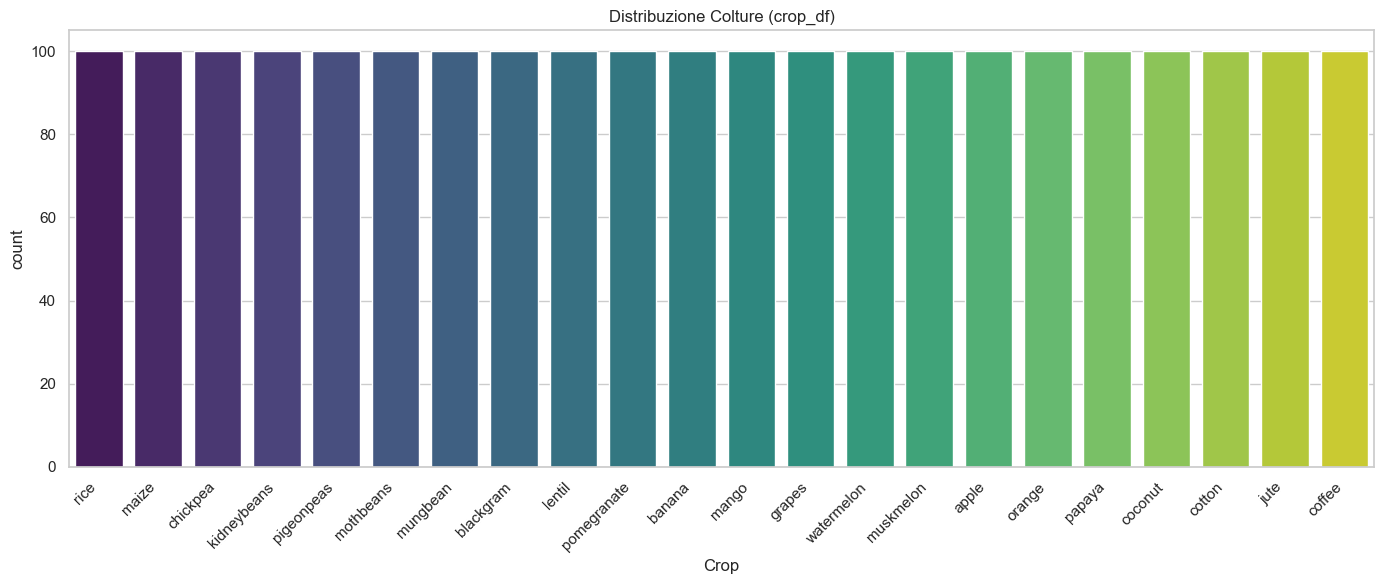

In [705]:
plt.figure(figsize=(14, 6))
sns.countplot(data=crop_df, x='Crop', hue='Crop', palette='viridis', order=crop_df["Crop"].value_counts().index)
plt.title("Distribuzione Colture (crop_df)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

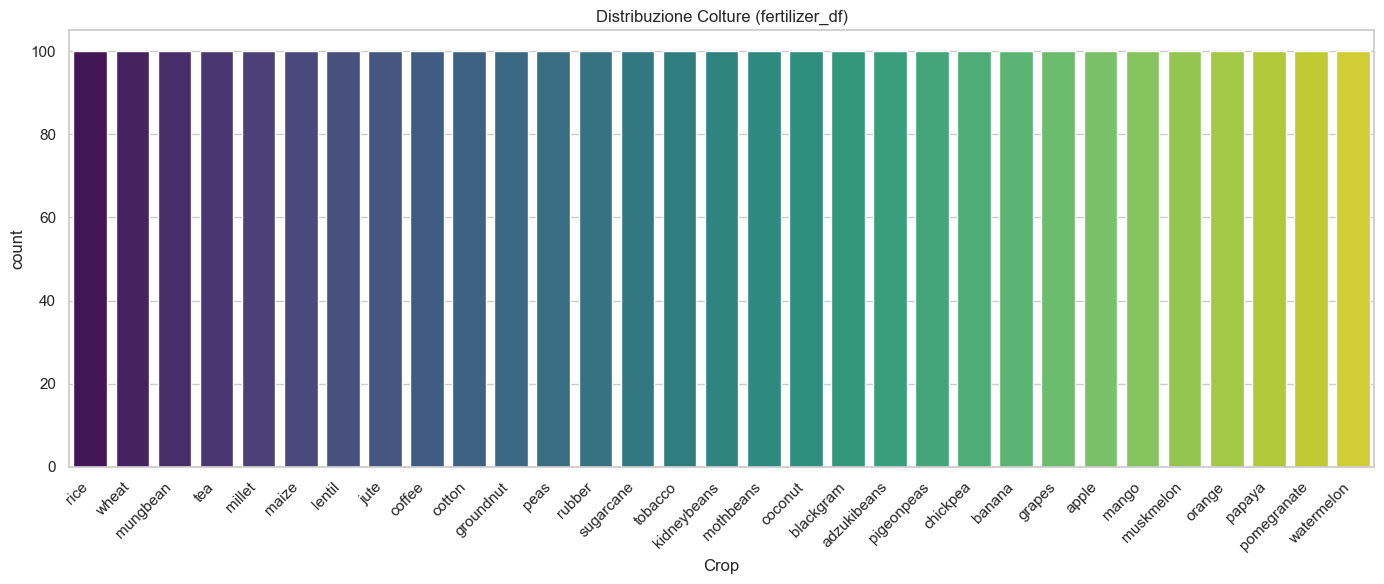

In [706]:
plt.figure(figsize=(14, 6))
sns.countplot(data=fertilizer_df, x='Crop', hue='Crop', palette='viridis', order=fertilizer_df["Crop"].value_counts().index)
plt.title("Distribuzione Colture (fertilizer_df)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Notiamo come entrambi i dataset presentino 100 campioni per coltura.
Per crop_df quindi non vi sono sbilanciamenti tra classi.

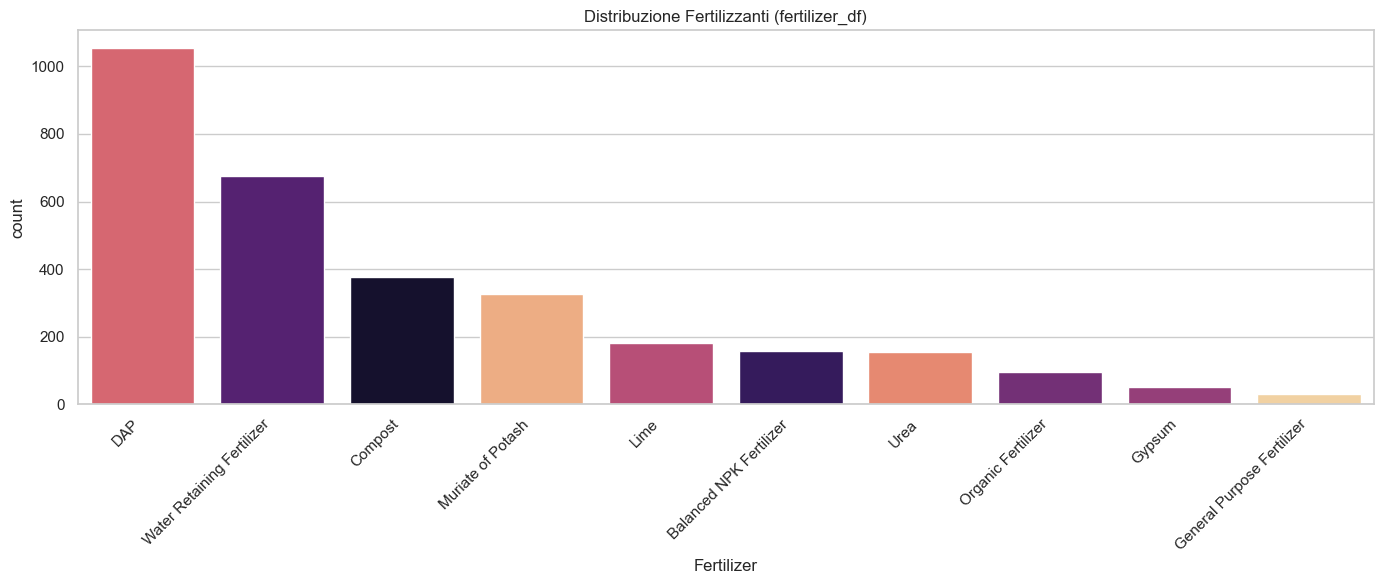

In [707]:
plt.figure(figsize=(14, 6))
sns.countplot(data=fertilizer_df, x='Fertilizer', hue='Fertilizer', palette='magma', order=fertilizer_df["Fertilizer"].value_counts().index)
plt.title("Distribuzione Fertilizzanti (fertilizer_df)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Per i fertilizzanti invece le classi sono fortemente sbilanciate.

Definiamo una funzione per fare il plot dei parametri chimici che andremmo ad analizzare

In [708]:
def plot_chemicals(chemical):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(crop_df[chemical], kde=True, color='blue', ax=axes[0])
    axes[0].set_title(chemical + ' crop_df', fontsize=12)
    axes[0].set_xlabel(chemical)

    sns.histplot(fertilizer_df[chemical], kde=True, color='red', ax=axes[1])
    axes[1].set_title(chemical + ' fertilizer_df', fontsize=12)
    axes[1].set_xlabel(chemical)

Valori di umidità rilevati:

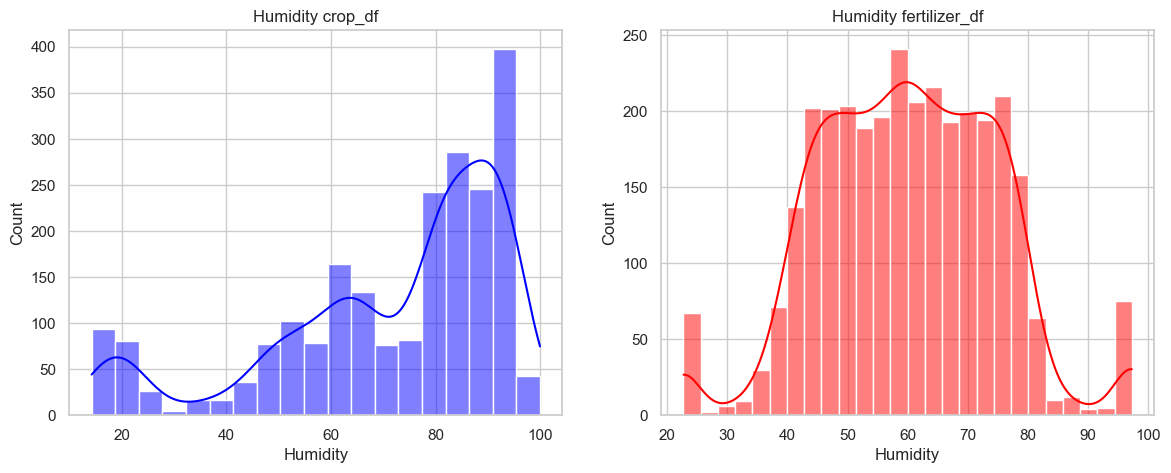

In [709]:
plot_chemicals('Humidity')

Temperature misurate:

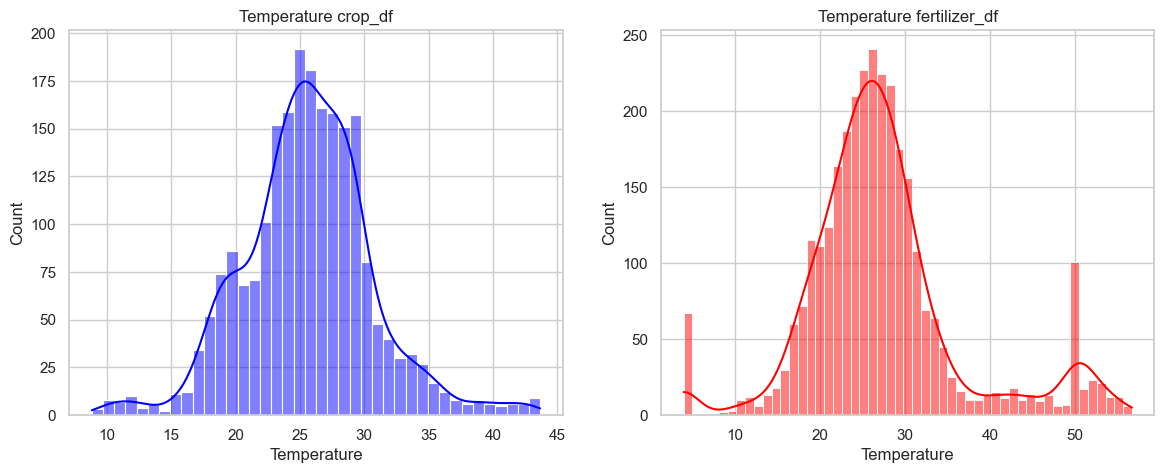

In [710]:
plot_chemicals('Temperature')

Precipitazioni misurate: 

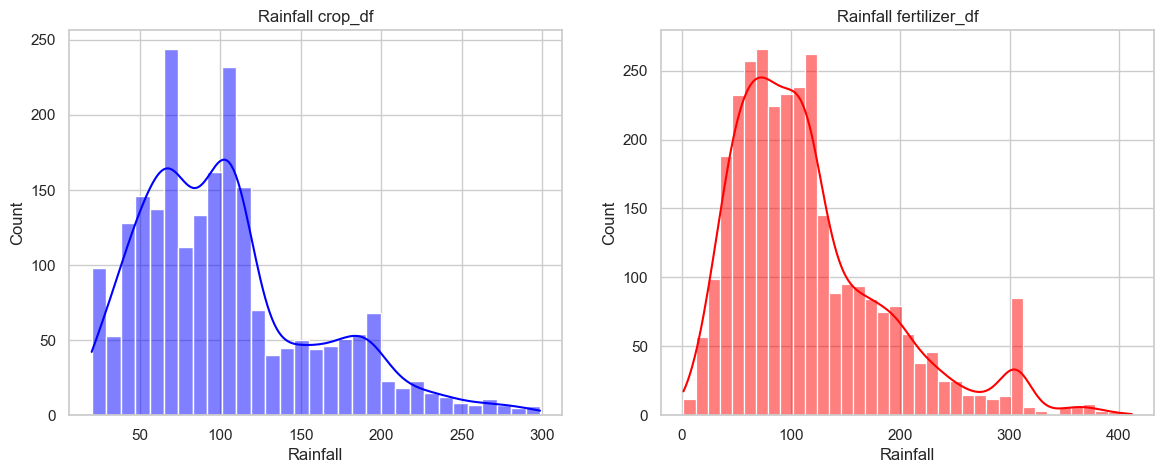

In [711]:
plot_chemicals('Rainfall')

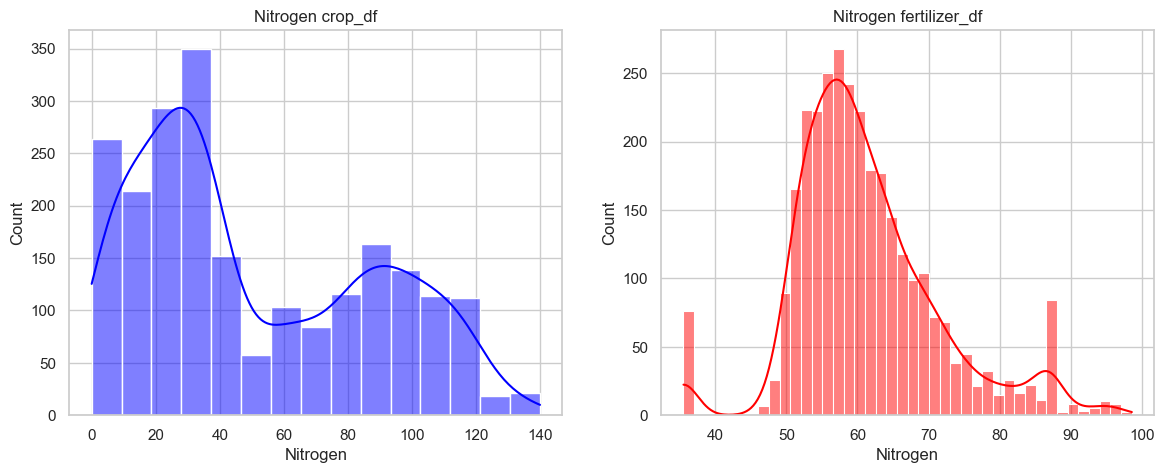

In [712]:
plot_chemicals('Nitrogen')

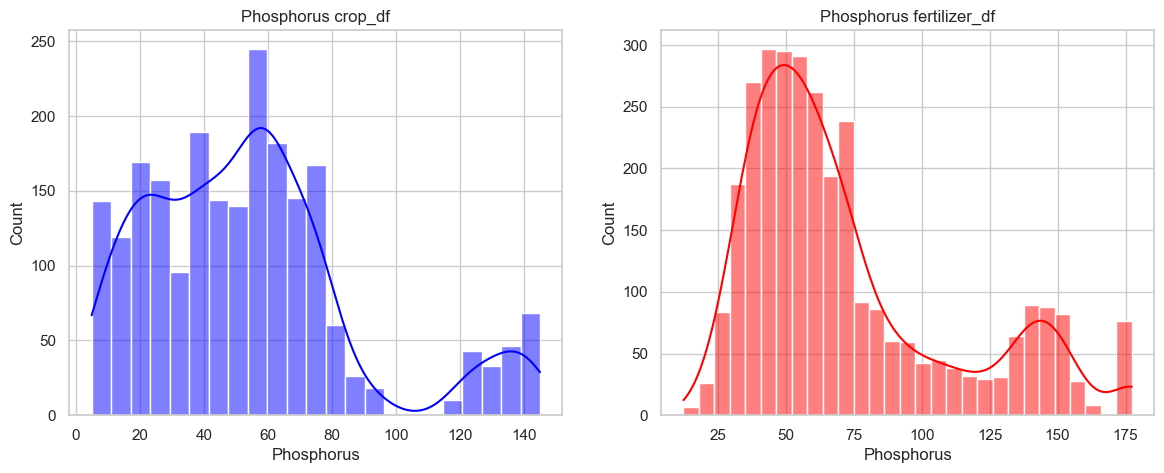

In [713]:
plot_chemicals('Phosphorus')

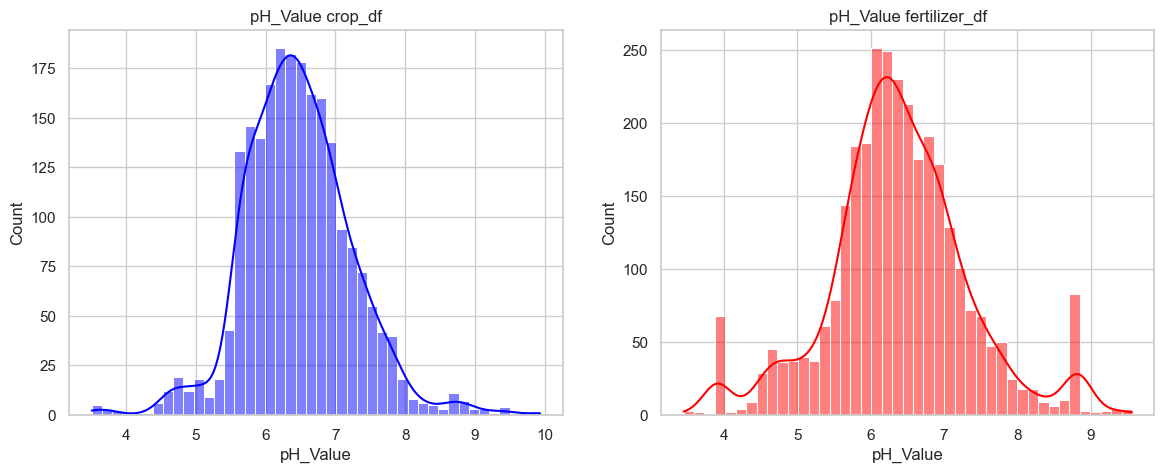

In [714]:
plot_chemicals('pH_Value')

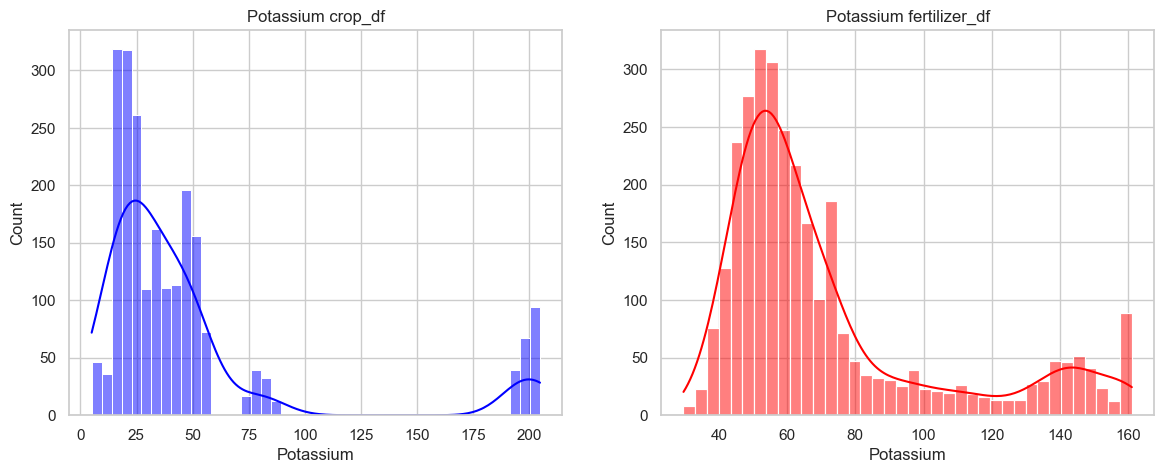

In [715]:
plot_chemicals('Potassium')

Notiamo un'incoerenza nel dataset `fertilizer_df`, in quanto i parametri `Rainfall`, `Potassium`, `Carbon` e `Phosphorus` misurano valori negativi. Essendo la misurazione delle precipitazioni in mm, non è possibile che si presentino valori negativi.

In [716]:
print((fertilizer_df[['Potassium', 'Carbon', 'Rainfall', 'Phosphorus']] < 0).sum())

Potassium     0
Carbon        0
Rainfall      0
Phosphorus    0
dtype: int64


### Correlazione tra variabili

Analizziamo la correlazione tra umidità e precipitazioni mediante coefficiente di Pearsonn.

Correlation between Humidity and Rainfall in crop_df: 0.17
Correlation between Humidity and Rainfall in fertilizer_df: -0.14


Text(0, 0.5, 'Rainfall (mm)')

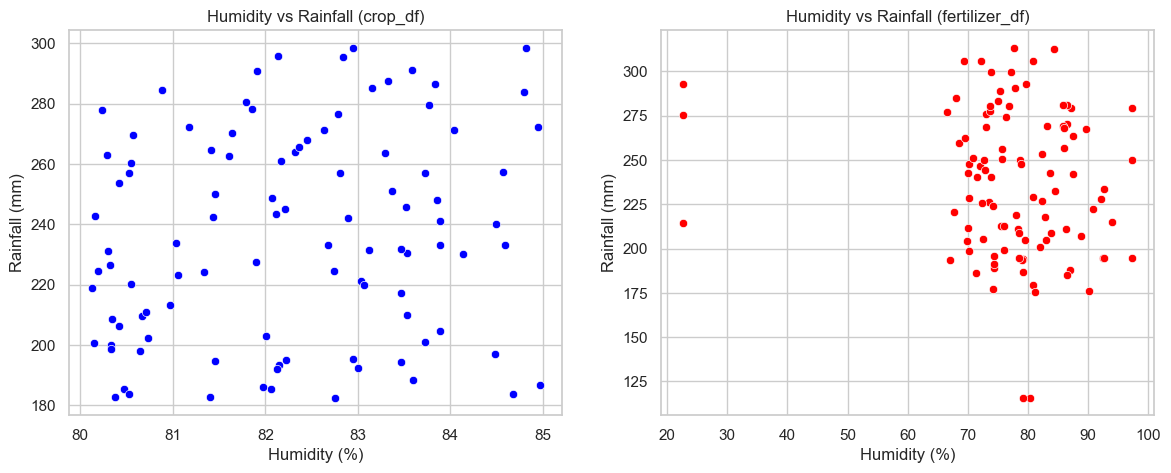

In [717]:
rice_crop = crop_df[crop_df["Crop"] == "rice"]
rice_fertilizer = fertilizer_df[fertilizer_df["Crop"] == "rice"]
hum_rain_corr_crop = rice_crop["Humidity"].corr(rice_crop["Rainfall"])
hum_rain_corr_fertilizer = rice_fertilizer["Humidity"].corr(rice_fertilizer["Rainfall"])

print(f"Correlation between Humidity and Rainfall in crop_df: {hum_rain_corr_crop:.2f}")
print(f"Correlation between Humidity and Rainfall in fertilizer_df: {hum_rain_corr_fertilizer:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x = rice_crop["Humidity"], y = rice_crop["Rainfall"], color='blue', ax=axes[0])
axes[0].set_title('Humidity vs Rainfall (crop_df)', fontsize=12)
axes[0].set_xlabel('Humidity (%)')
axes[0].set_ylabel('Rainfall (mm)')

sns.scatterplot(x = rice_fertilizer["Humidity"], y = rice_fertilizer["Rainfall"], color='red', ax=axes[1])
axes[1].set_title('Humidity vs Rainfall (fertilizer_df)', fontsize=12)
axes[1].set_xlabel('Humidity (%)')
axes[1].set_ylabel('Rainfall (mm)')


Notiamo come non vi sia correlazione tra le due variabili, probabilmente perchè il range dell'umidità è ristretto e perchè la relazione non è lineare. Tentiamo ora la stessa analisi con il coefficiente di Spearman.

In [718]:
rice_crop = crop_df[crop_df["Crop"] == "rice"]
rice_fertilizer = fertilizer_df[fertilizer_df["Crop"] == "rice"]
hum_rain_corr_crop = rice_crop["Humidity"].corr(rice_crop["Rainfall"], method='spearman')
hum_rain_corr_fertilizer = rice_fertilizer["Humidity"].corr(rice_fertilizer["Rainfall"], method='spearman')

print(f"Correlation between Humidity and Rainfall in crop_df: {hum_rain_corr_crop:.2f}")
print(f"Correlation between Humidity and Rainfall in fertilizer_df: {hum_rain_corr_fertilizer:.2f}")

Correlation between Humidity and Rainfall in crop_df: 0.17
Correlation between Humidity and Rainfall in fertilizer_df: -0.13


Il risultato è pressochè identico, confermando che tra le due variabili Humidity/Moisture e Rainfall non c'è correlazione.

Fatti questi due esempi possiamo usare i metodi di correlazione di Pandas con la heatmap di Seaborn per stampare le **matrici di correlazione**.

In [719]:
def plot_correlation_heatmap(df, title):
    numeric_df = df.select_dtypes(include=['number'])
    corr_matrix = numeric_df.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix,
                annot=True,          # Mostra i valori numerici all'interno delle celle
                fmt=".2f",           # Formatta i numeri a 2 cifre decimali
                cmap="coolwarm",     # Usa una mappa di colori dal blu (negativa) al rosso (positiva)
                vmin=-1, vmax=1,     # Fissa i limiti della scala da -1 a 1
                linewidths=0.5)      # Aggiunge una griglia per separare le celle
    plt.title(title, fontsize=16)
    plt.tight_layout()
    plt.show()

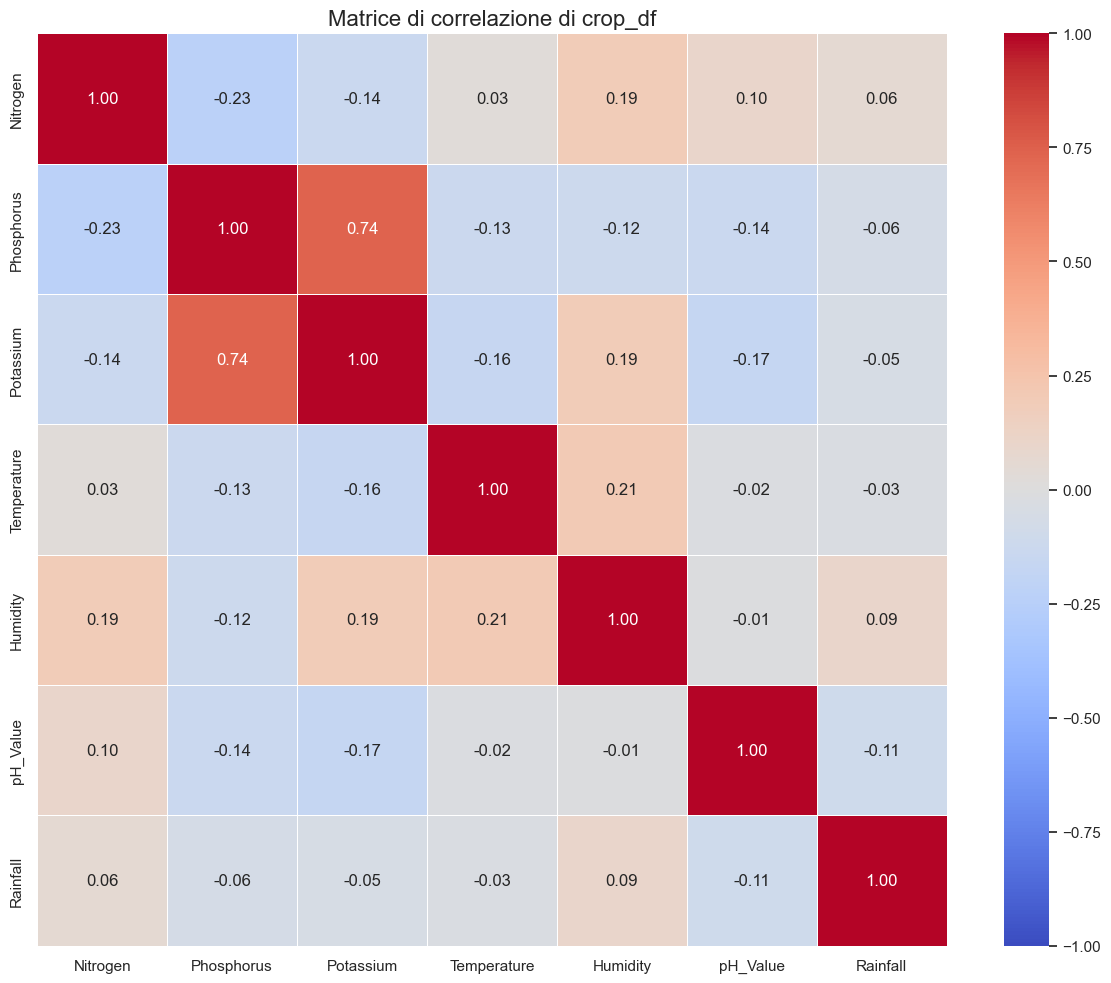

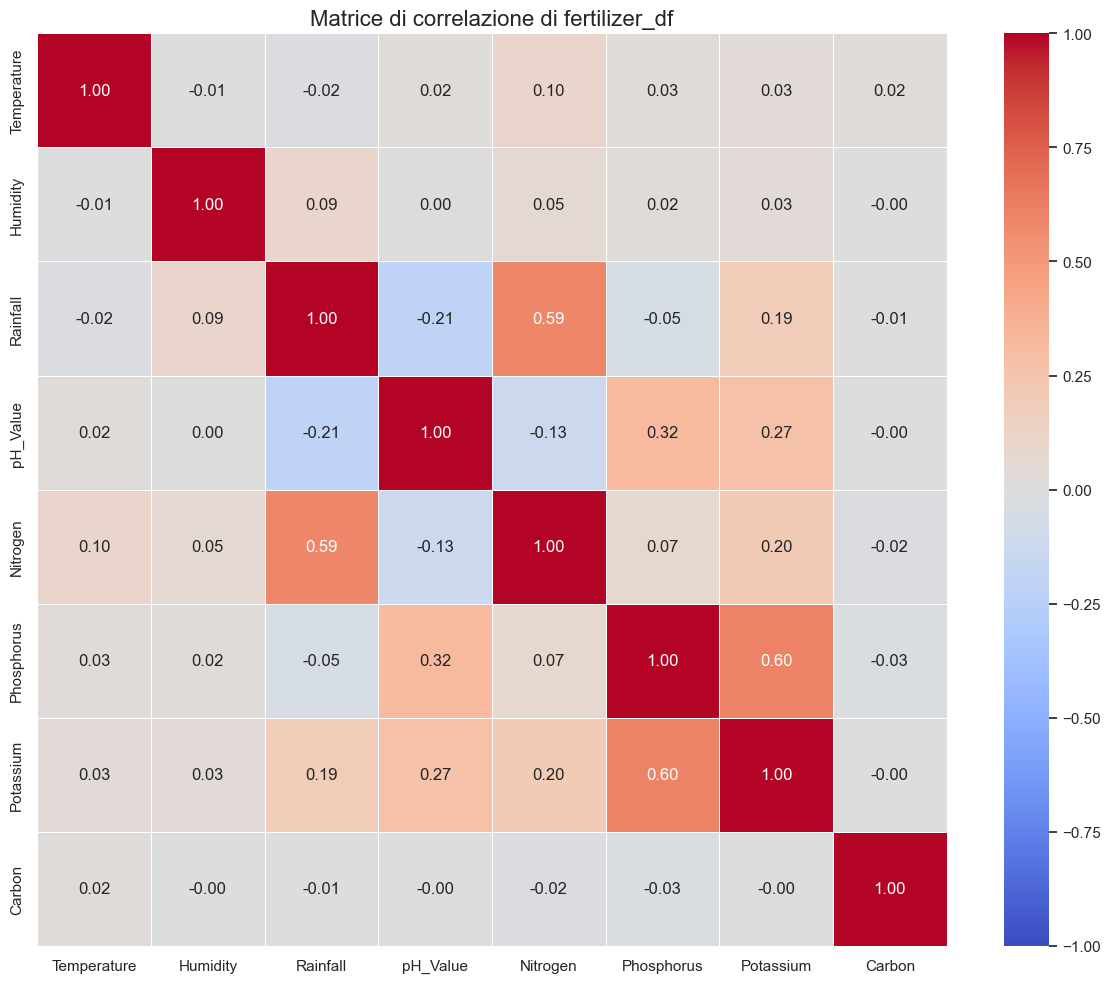

In [720]:
plot_correlation_heatmap(crop_df, "Matrice di correlazione di crop_df")
plot_correlation_heatmap(fertilizer_df, "Matrice di correlazione di fertilizer_df")

Sebbene in entrambi i dataset le colonne `Phosphorus` e `Potassium` abbiano un elevato indice di correlazione(0.74 nel primo caso e 0.60 nel secondo) non è sufficiente per eliminare una delle due colonne.

### Valutazione media e quartili

Valutiamo ora, per ogni coltura, i valori tipici di azoto, potassio, fosforo e temperatura.

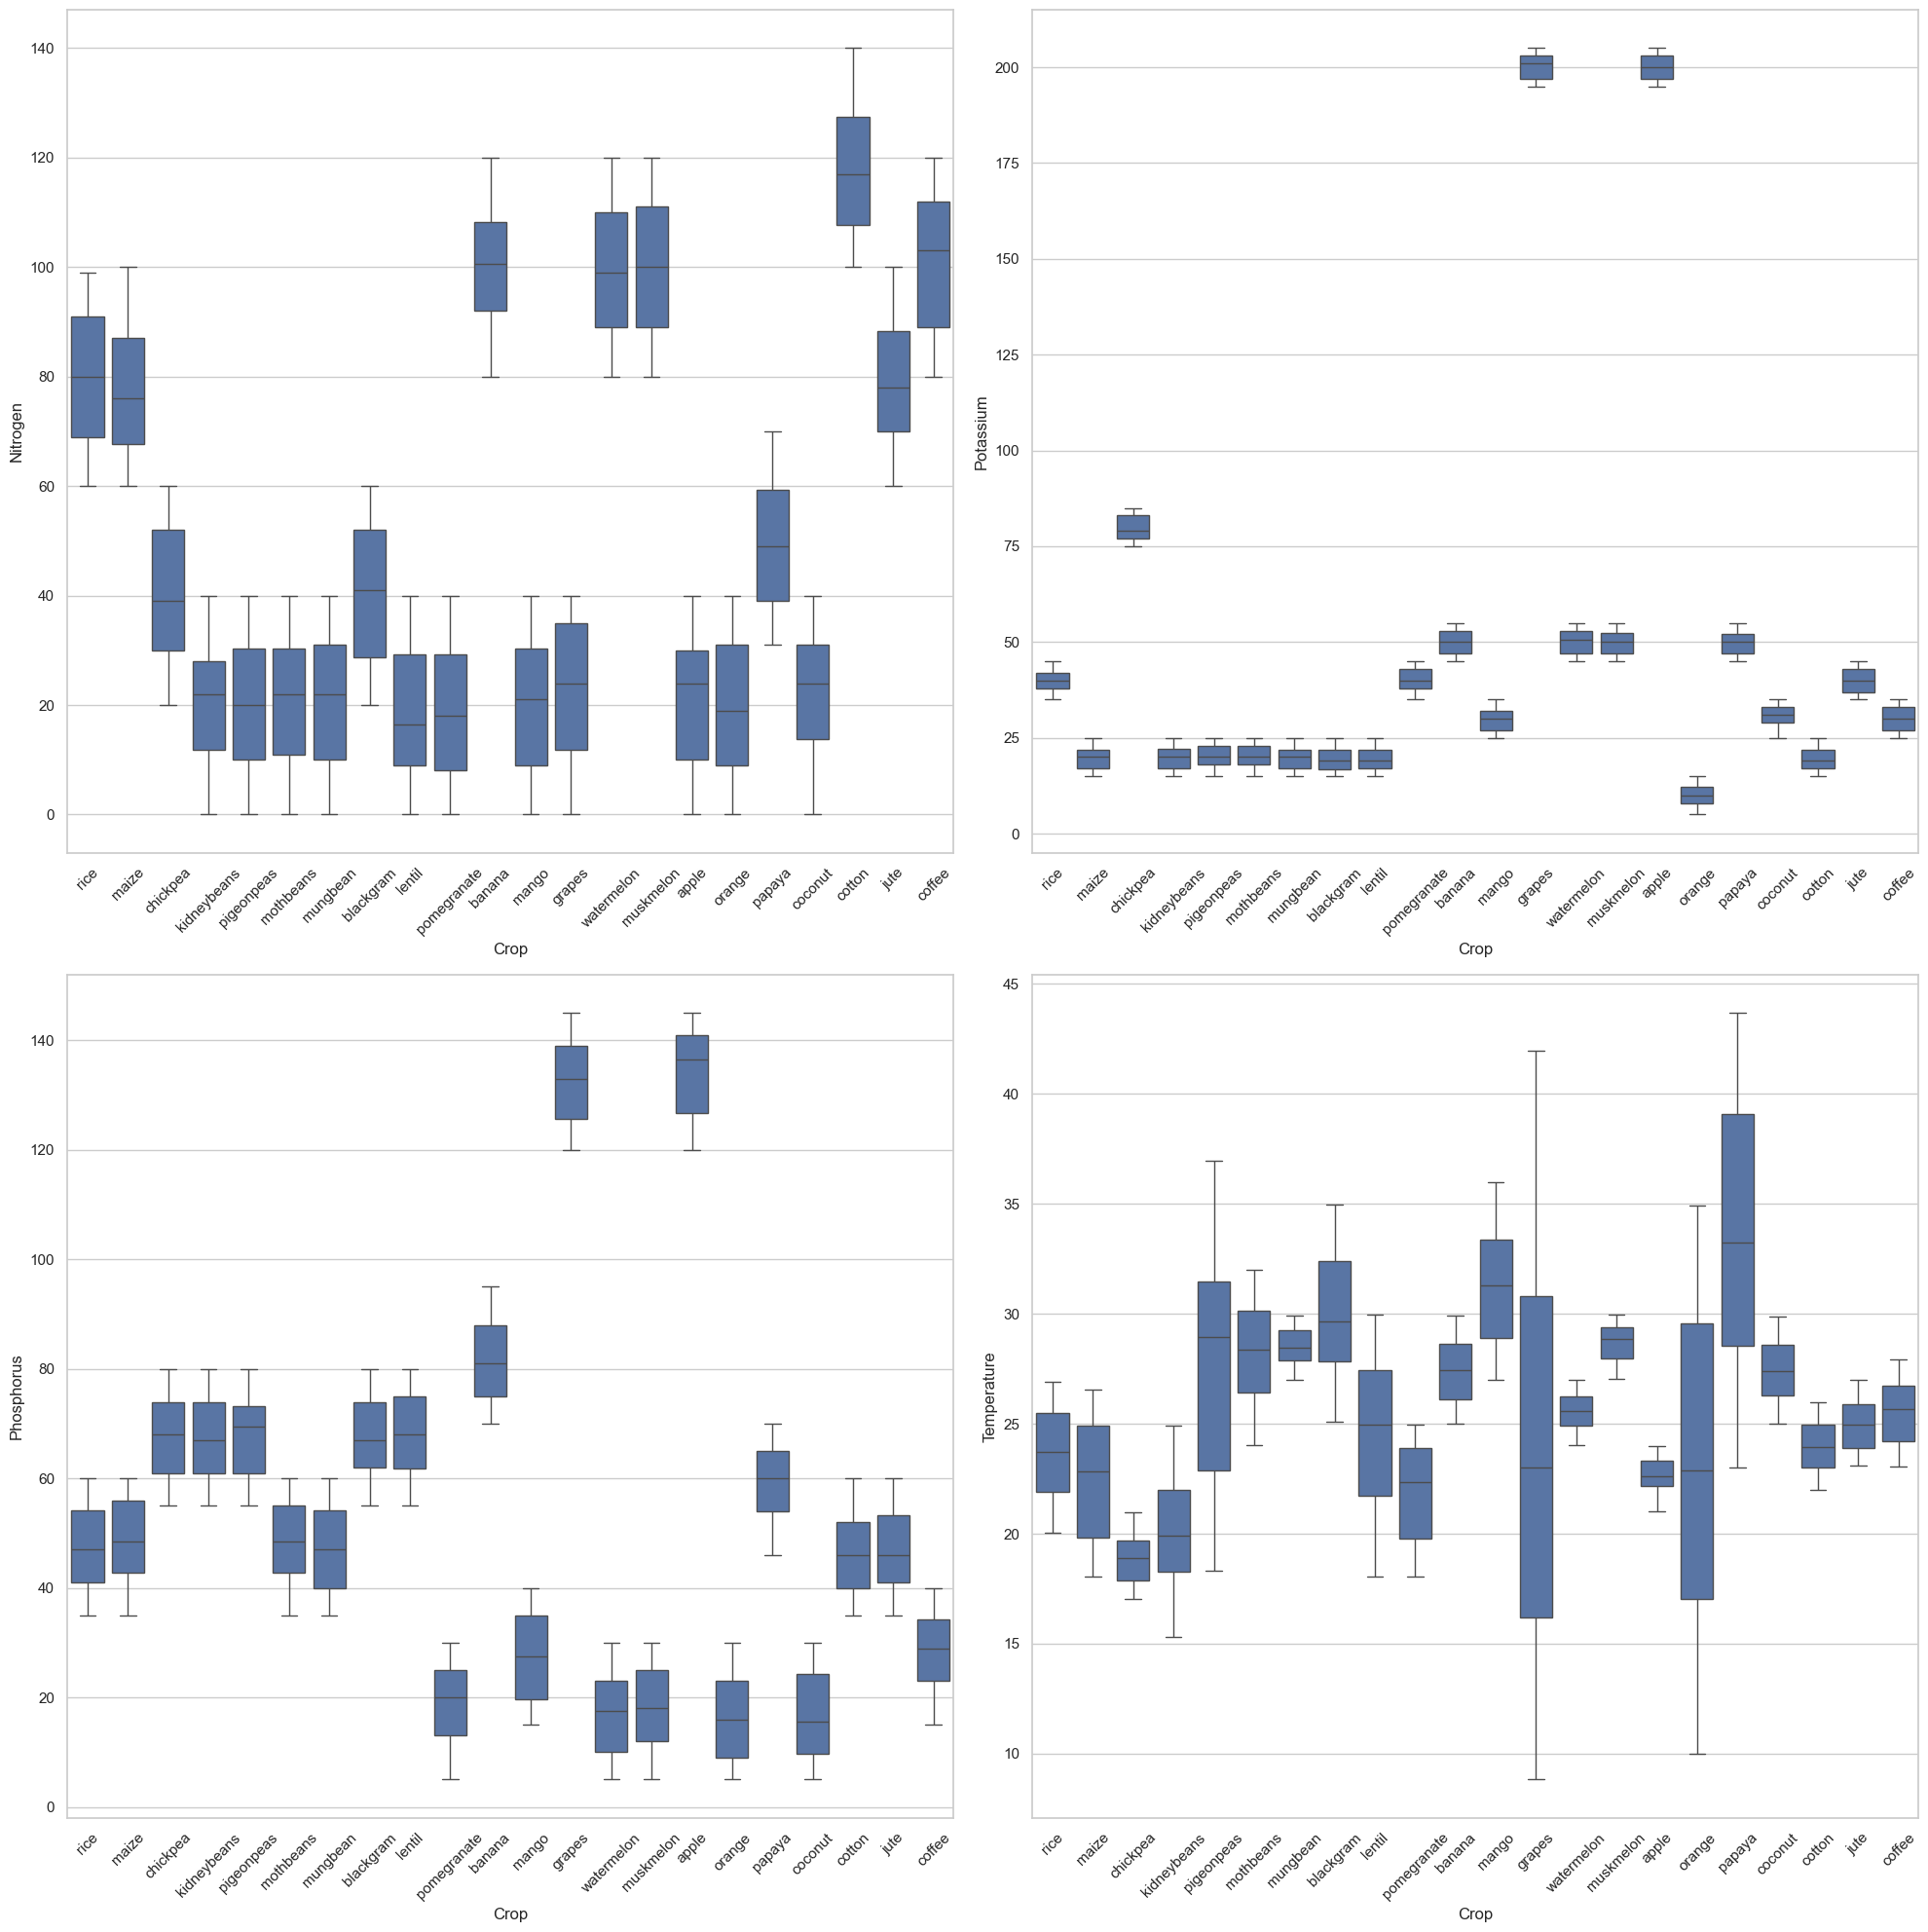

In [721]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
num_cols = ["Nitrogen", "Potassium", "Phosphorus", "Temperature"]

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=crop_df, x="Crop", y=col, ax=ax)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

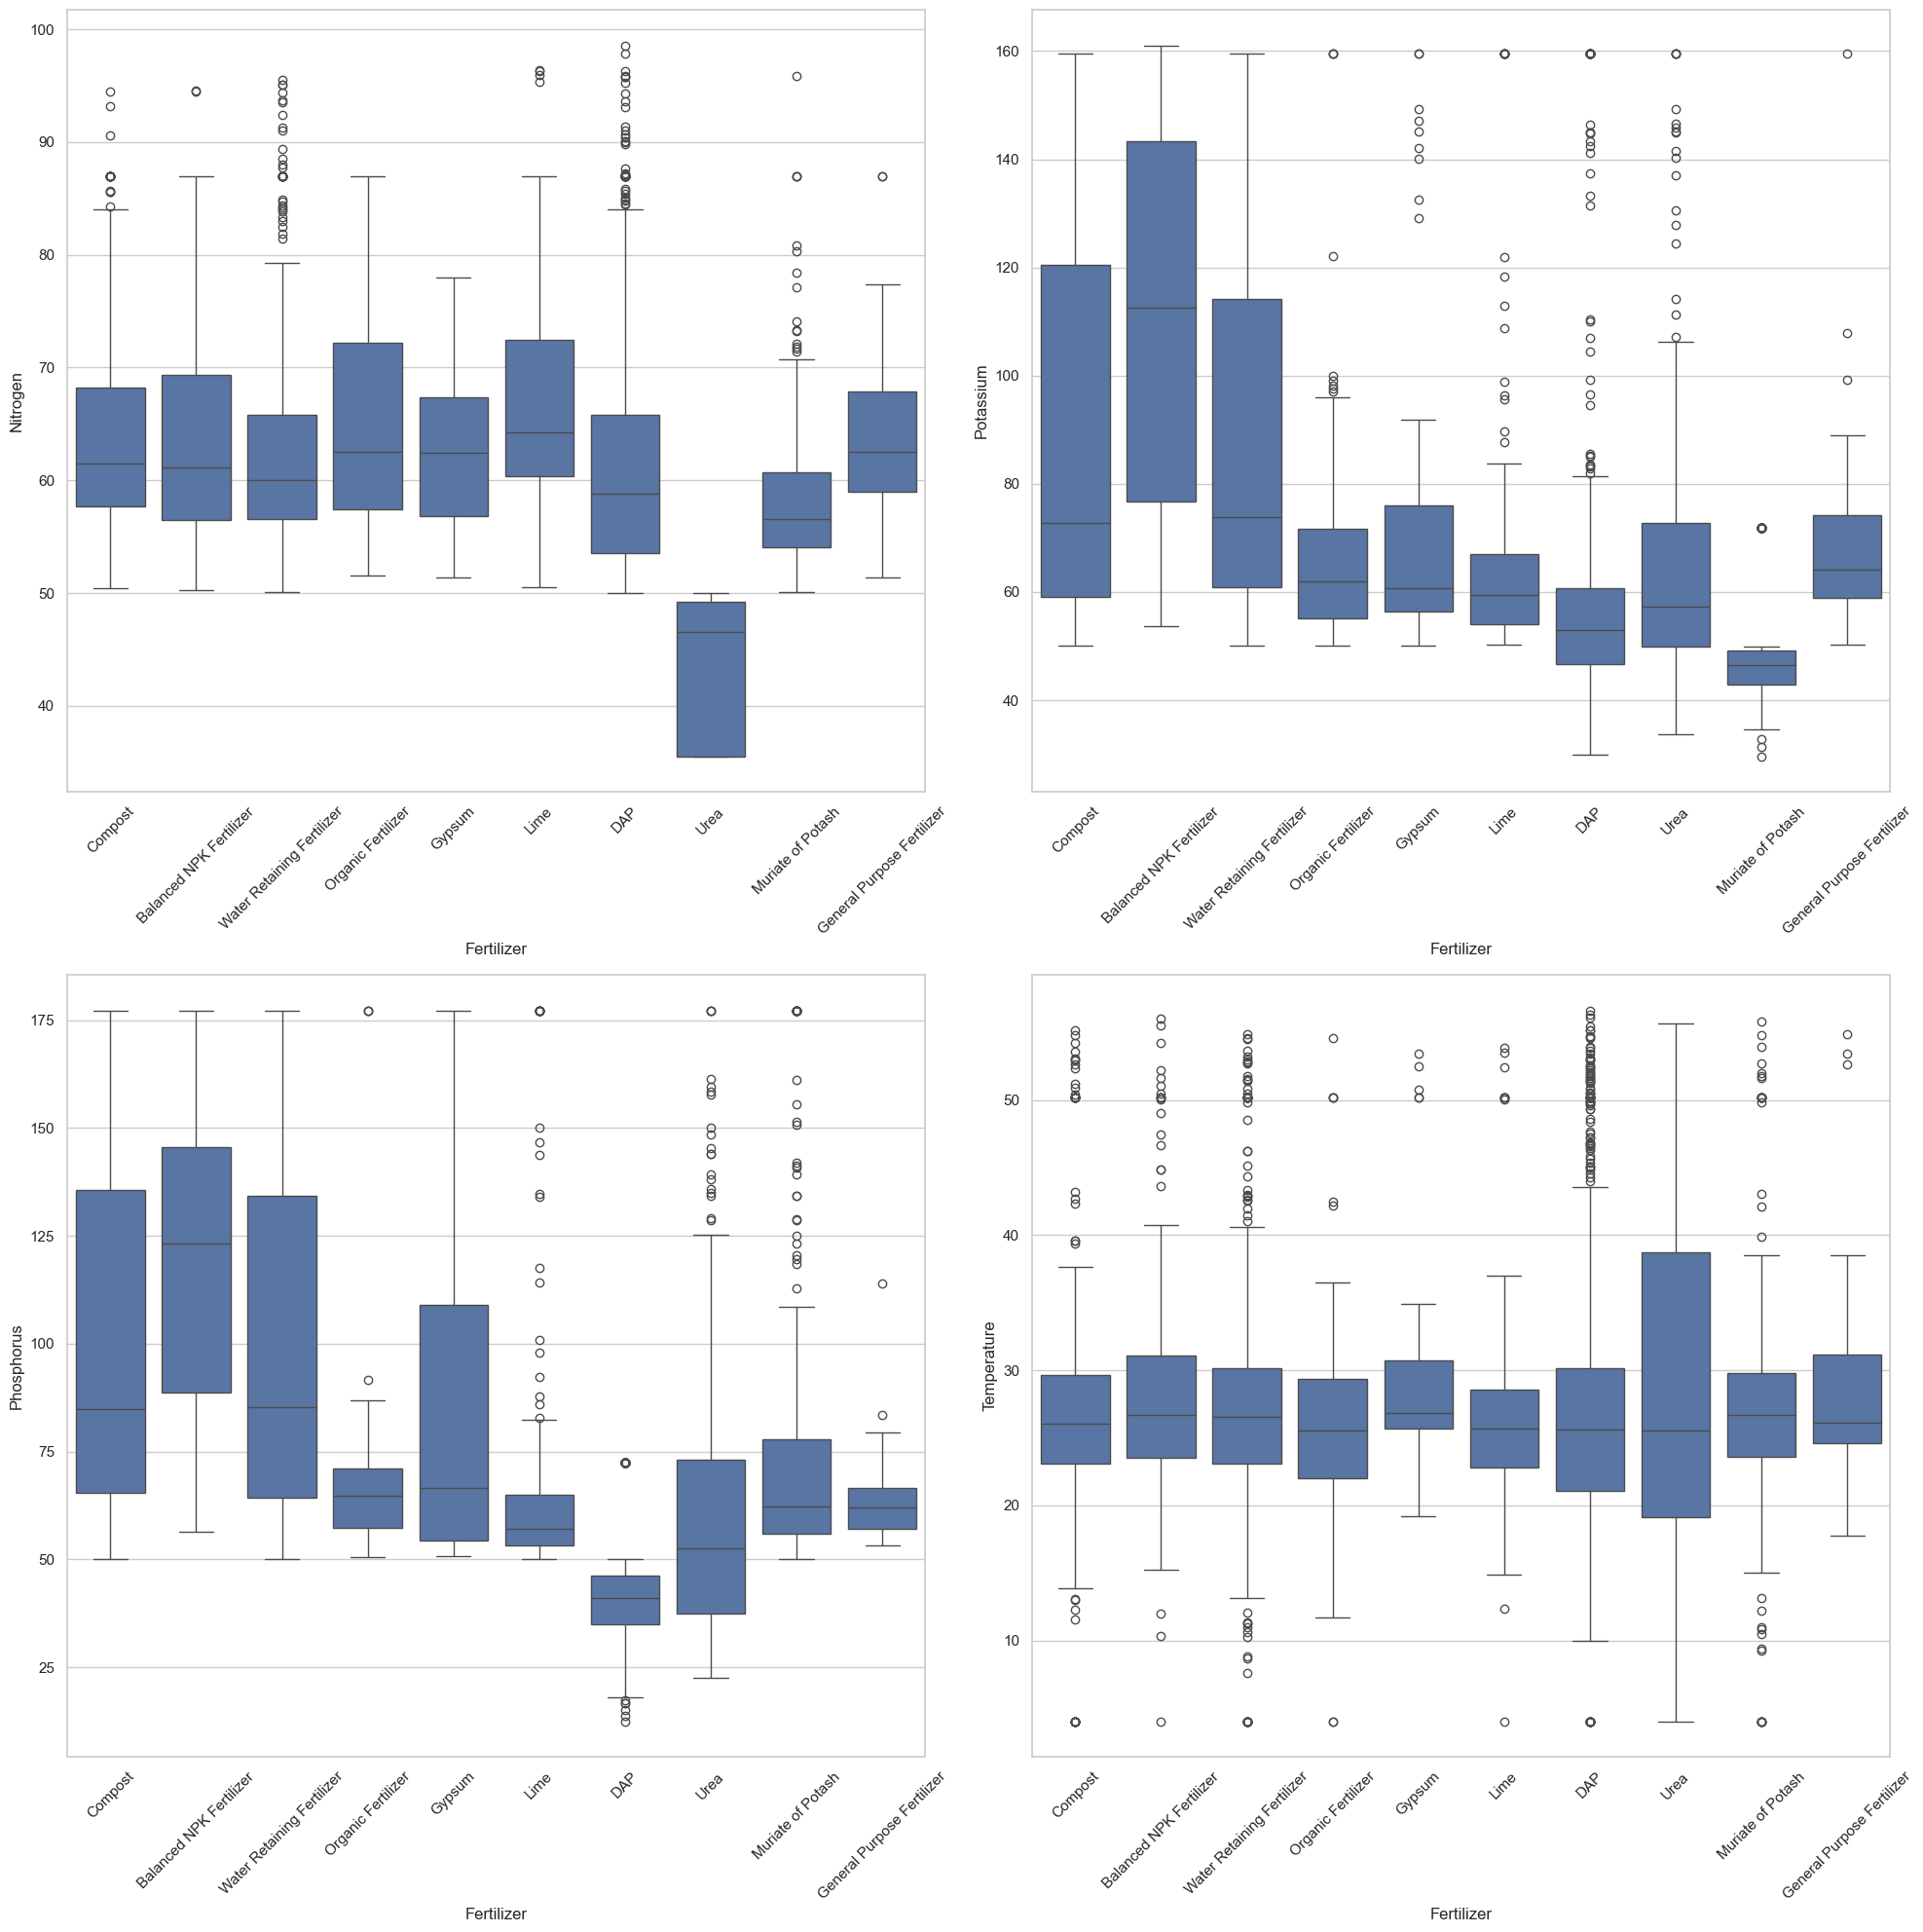

In [722]:
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
num_cols = ["Nitrogen", "Potassium", "Phosphorus", "Temperature"]

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=fertilizer_df, x="Fertilizer", y=col, ax=ax)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [723]:
fertilizer_df[["Fertilizer", "Phosphorus"]].sort_values("Phosphorus", ascending=False).head(3)

,Fertilizer,Phosphorus
2829,Balanced NPK Fertilizer,177.314481
2860,Water Retaining Fertilizer,177.314481
2838,Balanced NPK Fertilizer,177.314481


In [724]:
print((fertilizer_df['Phosphorus'] > 177).sum())
fertilizer_df['Phosphorus'].describe()

76


count    3100.000000
mean       72.350600
std        38.551347
min        12.445888
25%        44.565214
50%        60.019954
75%        86.108983
max       177.314481
Name: Phosphorus, dtype: float64

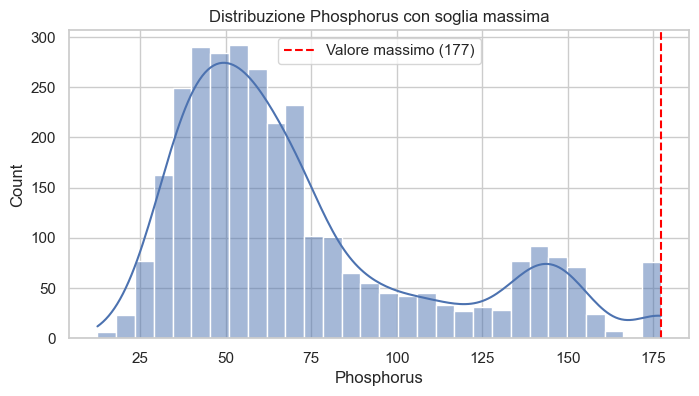

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(fertilizer_df["Phosphorus"], bins=30, kde=True)
plt.axvline(fertilizer_df["Phosphorus"].max(), color="red", linestyle="--", label="Valore massimo (177)")
plt.title("Distribuzione Phosphorus con soglia massima")
plt.legend()
plt.show()

I 76 valori pari al massimo (177 mg/kg) potrebbero riflettere una soglia di saturazione dello strumento di misura, un limite imposto dal protocollo di campionamento, o semplicemente terreni ad alto contenuto di fosforo.

La loro distribuzione uniforme tra le classi (se confermato) suggerisce che non introducano un bias sistematico nel modello. Si è scelto di mantenerli.

### Fusione tra dataset

In [726]:
column_names = ["Temperature", "Humidity", "Rainfall", "pH_Value", "Nitrogen", "Phosphorus", "Potassium", "Crop"]

merged_df = pd.concat([
    fertilizer_df[column_names],
    crop_df[column_names]],
    axis=0,
    join='outer',
    ignore_index=True
)

merged_df.describe()

,Temperature,Humidity,Rainfall,pH_Value,Nitrogen,Phosphorus,Potassium
count,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000,5300.000000
mean,26.584176,64.810676,110.675214,6.417011,56.825904,64.468842,62.003799
std,7.738820,18.977798,65.039306,0.886707,25.577369,37.526754,42.638623
min,4.011486,14.258040,1.322761,3.448974,0.000000,5.000000,5.000000
25%,22.568594,51.613282,64.691423,5.906321,43.000000,39.912103,37.994934
50%,25.880595,65.021032,97.733591,6.379491,57.932264,56.312470,52.000000
75%,29.221322,79.927009,139.651522,6.907896,68.606625,75.000000,69.996432
max,56.653592,99.981876,411.955947,9.935091,140.000000,177.314481,205.000000


In [ ]:
# TODO: Analisi di merged_df

# Addestramento dei modelli
Una volta estratte le feature più importanti possiamo passare al tipo di modello che vogliamo addestrare.

## Modello 1

TODO: Da modificare

In [727]:
y_merged = merged_df['Crop']
X_merged = merged_df.drop('Crop', axis=1)

In [728]:
X_train_merged, X_test_merged, y_train_merged, y_test_merged = train_test_split(X_merged, y_merged, test_size=0.30, random_state=42)

Definiamo una funzione generale utile per i classificatori. Attualmente stiamo analizzando dati *numerici*, quindi non abbiamo bisogno di One-Hot Encoding o tecniche complesse per elaborare i dati. L'unico strumento di preprocessing incluso è quindi`StandardScaler`.

In [729]:
def build_scaled_classificator(classifier):
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("classifier", classifier)
    ])

In [730]:
def build_model_with_classifier(model, param_grid, X, y):
    cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rnd_search_m = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,
        cv=cv_stratified,
        scoring="accuracy",
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    rnd_search_m.fit(X, y)
    return rnd_search_m

In [731]:
def print_model_heatmap(model, cm, title):
    plt.figure(figsize=(16, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_,
                yticklabels=model.classes_)
    plt.title(f"Heatmap of {title} data", fontsize=16)
    plt.xlabel(f"{title} - Predicted", fontsize=12)
    plt.ylabel(f"{title} - Actual", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()

### Perceptron

In [732]:
perc_base = Perceptron(random_state=42, max_iter=2000)

perc_scaled_pipeline = build_scaled_classificator(perc_base)

param_grid_perc = {
    'classifier__penalty': [None, 'l2', 'l1', 'elasticnet'],
    'classifier__alpha': [0.0001, 0.001, 0.01]
}

rnd_search_perc_base = build_model_with_classifier(perc_scaled_pipeline, param_grid_perc, X_train_merged, y_train_merged)
best_perc = rnd_search_perc_base.best_estimator_

print(f"\nBest params: {rnd_search_perc_base.best_params_}")
print(f"Accuracy in CV: {rnd_search_perc_base.best_score_ * 100:.2f}%")

best_perc = rnd_search_perc_base.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params: {'classifier__penalty': 'l2', 'classifier__alpha': 0.0001}
Accuracy in CV: 22.99%


In [733]:
from sklearn.preprocessing import PolynomialFeatures

def build_poly_scaled_classificator(classifier, degree=2):
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("classifier", classifier)
    ])

In [734]:
perc_poly_pipeline = build_poly_scaled_classificator(perc_base, degree=2)

rnd_search_perc_poly = build_model_with_classifier(perc_poly_pipeline, param_grid_perc, X_train_merged, y_train_merged)

print(f"\nBest params: {rnd_search_perc_poly.best_params_}")
print(f"Accuracy in CV: {rnd_search_perc_poly.best_score_ * 100:.2f}%")

best_perc = rnd_search_perc_poly.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params: {'classifier__penalty': 'l1', 'classifier__alpha': 0.0001}
Accuracy in CV: 56.63%


### Logistic Regression


In [735]:
lr_scaled = build_scaled_classificator(LogisticRegression(random_state=42, max_iter=2000))

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__solver': ['lbfgs', 'saga'],
    'classifier__class_weight': [None, 'balanced']
}

rnd_search_lr = build_model_with_classifier(lr_scaled, param_grid_lr, X_train_merged, y_train_merged)

print(f"\nBest params: {rnd_search_lr.best_params_}")
print(f"Accuracy in CV: {rnd_search_lr.best_score_ * 100:.2f}%")

best_pipeline_model1_lr = rnd_search_lr.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params: {'classifier__solver': 'saga', 'classifier__class_weight': 'balanced', 'classifier__C': 10}
Accuracy in CV: 58.22%


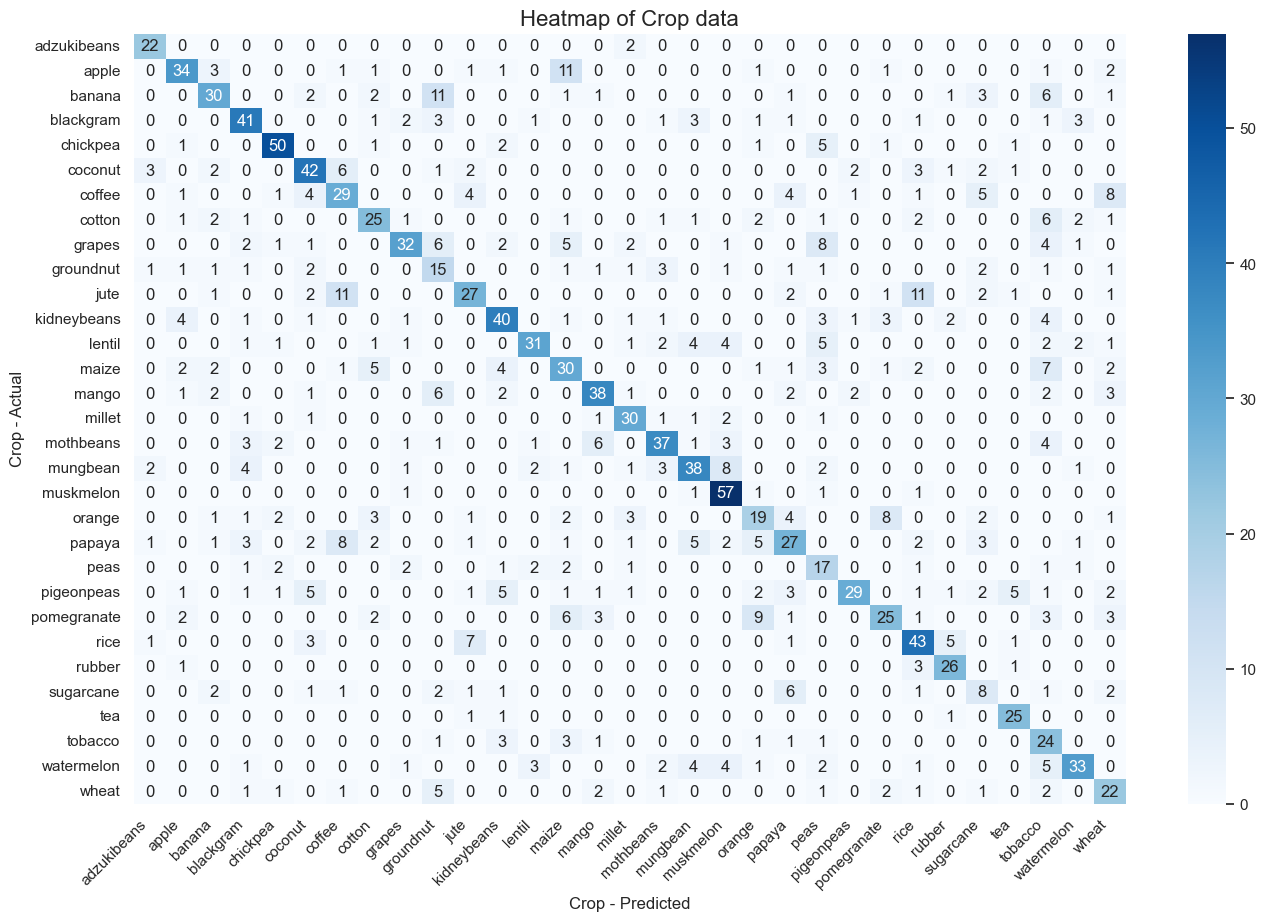

In [736]:
y_pred_lr = best_pipeline_model1_lr.predict(X_test_merged)
cm_lr = confusion_matrix(y_test_merged, y_pred_lr, labels=best_pipeline_model1_lr.classes_)
print_model_heatmap(best_pipeline_model1_lr, cm_lr, "Crop")

### SVM

Laura

### Random Forest

In [737]:
# griglia di parametri per Random Forest
param_grid = {
    'classifier__n_estimators': [50, 100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30, 40],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2', None]
}

In [738]:
rf_scaled = build_scaled_classificator(RandomForestClassifier(random_state=42))

cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rnd_search_rf_1 = RandomizedSearchCV(
    estimator=rf_scaled,
    param_distributions=param_grid,
    n_iter=10,
    cv=cv_stratified,
    scoring="accuracy",
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rnd_search_rf_1.fit(X_train_merged, y_train_merged)

print(f"\nBest params: {rnd_search_rf_1.best_params_}")
print(f"Accuracy in CV: {rnd_search_rf_1.best_score_ * 100:.2f}%")

best_pipeline_model1_rf = rnd_search_rf_1.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}
Accuracy in CV: 75.71%



--- REPORT (RANDOM FOREST) ---
              precision    recall  f1-score   support

 adzukibeans       0.95      0.83      0.89        24
       apple       0.69      0.86      0.77        57
      banana       0.73      0.75      0.74        59
   blackgram       0.72      0.78      0.75        59
    chickpea       0.89      0.92      0.90        62
     coconut       0.82      0.89      0.85        65
      coffee       0.71      0.71      0.71        58
      cotton       0.66      0.74      0.70        47
      grapes       0.79      0.69      0.74        65
   groundnut       0.51      0.65      0.57        34
        jute       0.74      0.68      0.71        59
 kidneybeans       0.90      0.87      0.89        63
      lentil       0.80      0.66      0.73        56
       maize       0.79      0.62      0.70        61
       mango       0.72      0.80      0.76        60
      millet       0.92      0.92      0.92        38
   mothbeans       0.89      0.83      0.86      

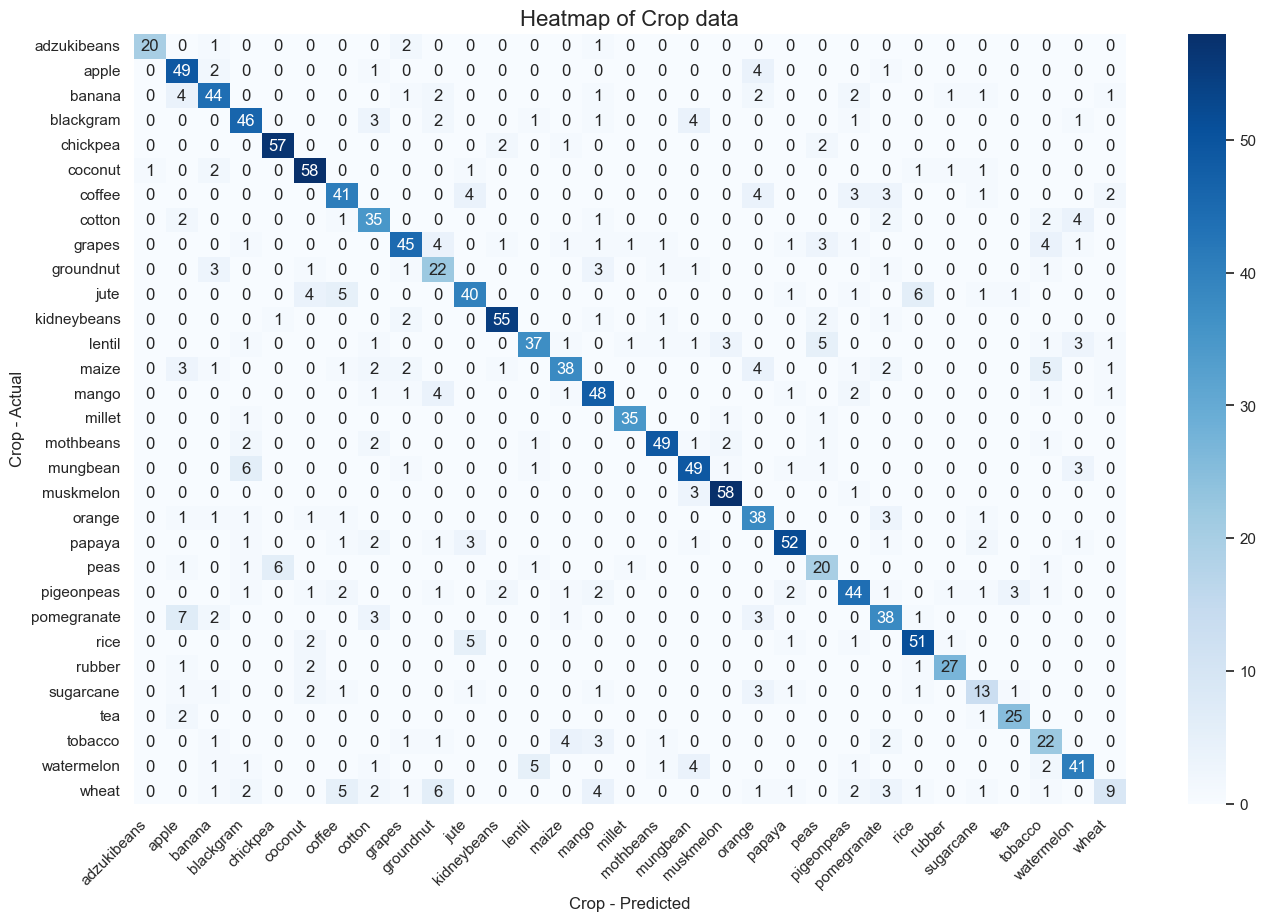

In [739]:
y_pred_rf_merged = best_pipeline_model1_rf.predict(X_test_merged)

print("\n--- REPORT (RANDOM FOREST) ---")
print(classification_report(y_test_merged, y_pred_rf_merged))

cm_rf_1 = confusion_matrix(y_test_merged, y_pred_rf_merged, labels=best_pipeline_model1_rf.classes_)

print_model_heatmap(best_pipeline_model1_rf, cm_rf_1, "Crop")

Riassumendo in una funzione:
Viene creato il modello di classificazione con i parametri selezionati da randomized search, applicando la stratified Kfold.

### XGBoost

XGBoost attende delle etichette *numeriche*, perciò è necessario utilizzare `LabelEncoder`per modificarle, prima che esse vengano passate al modello

In [740]:
le = LabelEncoder()
y_test_enc = le.fit_transform(y_test_merged)
y_train_enc = le.fit_transform(y_train_merged)

In [741]:
param_grid_xgb = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth": [3, 5, 7, 9],
    "classifier__subsample": [0.8, 0.9, 1.0]
}

xgb = build_scaled_classificator(XGBClassifier(random_state=42, eval_metric="mlogloss", n_jobs=-1, error_score="raise"))

rnd_search_xgb_1 = build_model_with_classifier(xgb, param_grid_xgb, X_train_merged, y_train_enc)

print(f"\nBest params: {rnd_search_xgb_1.best_params_}")
print(f"Accuracy in CV: {rnd_search_xgb_1.best_score_ * 100:.2f}%")

best_pipeline_model1_xgb = rnd_search_xgb_1.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


c:\pandora\data-intensive\progetto\DIA-project-2025\data-intensive-project\diaenv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:21:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "error_score" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 200, 'classifier__max_depth': 9, 'classifier__learning_rate': 0.05}
Accuracy in CV: 76.63%


Per rappresentare con label testuali anzichè numeriche:

In [742]:
def print_model_heatmap_encoded(model, cm, title, classes):
    plt.figure(figsize=(16, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes,
                yticklabels=classes)
    plt.title(f"Heatmap of {title} data", fontsize=16)
    plt.xlabel(f"{title} - Predicted", fontsize=12)
    plt.ylabel(f"{title} - Actual", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.show()

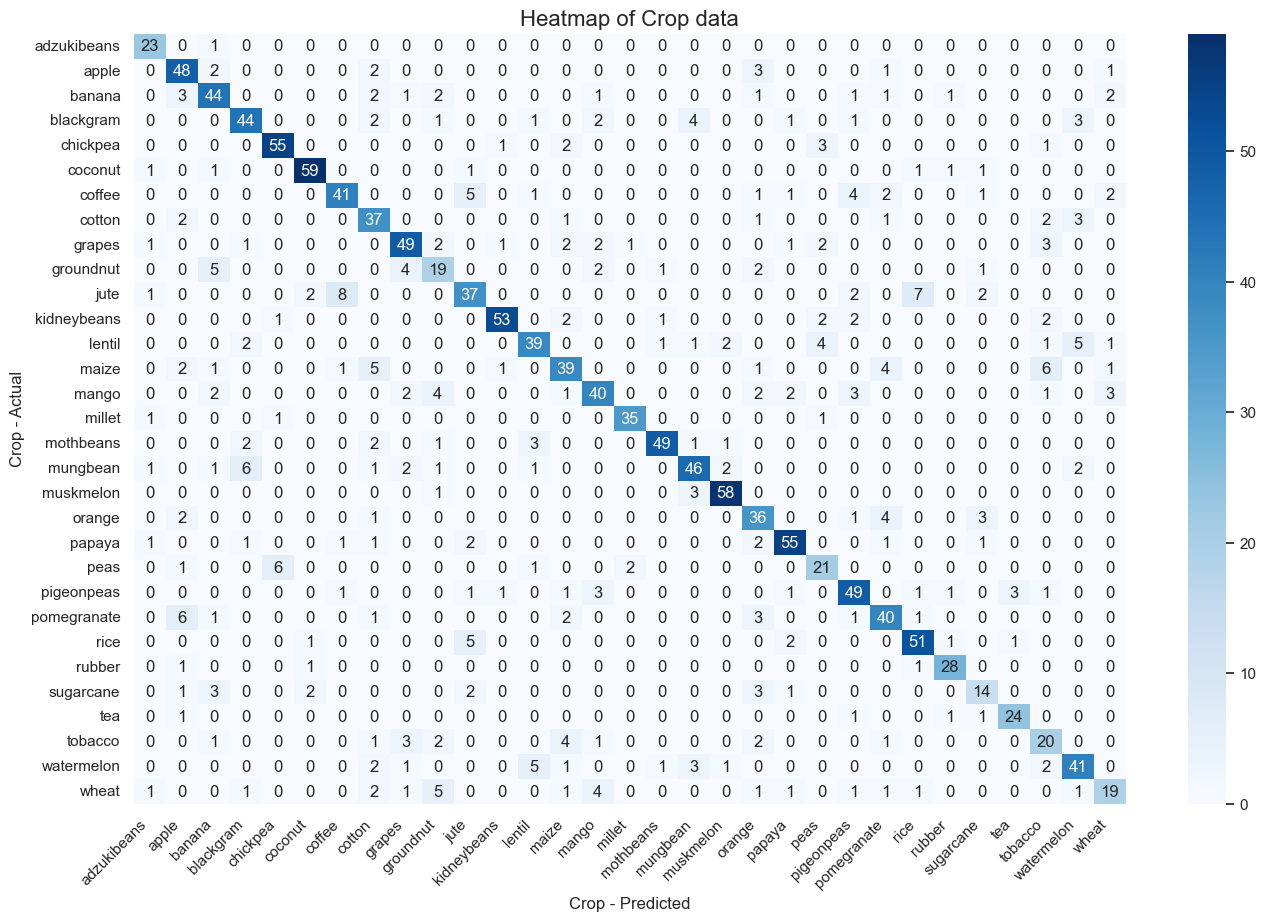

In [743]:
y_pred_xgb = best_pipeline_model1_xgb.predict(X_test_merged)

cm_xgb = confusion_matrix(y_test_enc, y_pred_xgb, labels=best_pipeline_model1_xgb.classes_)
print_model_heatmap_encoded(best_pipeline_model1_xgb, cm_xgb, "Crop", le.classes_)

## Benchmark

In [744]:
best_model1 = rnd_search_rf_1.best_estimator_

In [745]:
best_model1 #placeholder

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5


# Modello 2

Questo modello dovrà predire la feature `fertilizer` sfruttando il dataset `fertilizer_df`, una volta effettuate alcune necessarie modifiche. 
(da togliere colonna remark)

- La prima versione, chiamata `rnd_search_rf_2` sfrutta l'algoritmo *Random Forest*.   
- La seconda: `rnd_rearch_xgb_2` sfrutta invece *XGBoost*.

### Preparazione dei dati

Il secondo modello sfrutterà anche le colonne del dataset che presentano dati di tipo **categorico**. Di conseguenza bisogna ragionare sulla codifica di questi dati in modo da poterli inserire nel modello di predizione. L'approccio standard, seguito anche da noi è quello dell'**One-Hot Encoding**, attraverso il quale il dato viene codificato sfruttando un numero di colonne pari alle categorie, delle quali solo quella corrispondente alla variabile in analisi presenterà valore 1. Per esempio, se nella fase precedente abbiamo trovato che una riga presenta la coltura `rice` allora nel dataset che dovremmo esaminare, tale riga avrà, in corrispondenza della colonna `Crop_rice`, il valore 1, mentre per le altre avrà 0.

Pipeline che suddivide le colonne in base al tipo: categorico o numerico.

In [746]:
def cat_num(df):
    categorical = df.select_dtypes(include=['object', 'str']).columns
    numeric = df.select_dtypes(include=['number']).columns
    return categorical, numeric

In [747]:
#fertilizer_df senza colonna "Remark"
fertilizer_df = fertilizer_df.drop(columns=["Remark"])
fertilizer_df_data = fertilizer_df.drop(columns=["Fertilizer"])
fertilizer_column = fertilizer_df["Fertilizer"]

# Divisione tra colonne categoriche e numeriche
categorical, numeric = cat_num(fertilizer_df_data)


In [748]:
print("fertilizer_df columns:")
print("categorical:\t",categorical)
print("numeric:\t",numeric)

fertilizer_df columns:
categorical:	 Index(['Soil', 'Crop'], dtype='str')
numeric:	 Index(['Temperature', 'Humidity', 'Rainfall', 'pH_Value', 'Nitrogen',
       'Phosphorus', 'Potassium', 'Carbon'],
      dtype='str')


Definiamo un transformer che distingua l'operazione da effettuare tra colonne numeriche e categoriche:

In [749]:
def build_scaled_encoded_preprocessor(numeric, categorical):
    return ColumnTransformer([
        ("numeric", StandardScaler(), numeric ),
        ("categorical", OneHotEncoder(drop='first', sparse_output=False), categorical)
    ])

Sfruttiamo tale preprocessore per costruire la pipeline del classificatore:

In [750]:
def build_scaled_encoded_classificator(classifier, numeric, categorical):
    return Pipeline([
        ("preprocessor", build_scaled_encoded_preprocessor(numeric, categorical)),
        ("classifier", classifier)
    ])

### Gestione classi sbilanciate

In questa fase abbiamo una particolarità: le classi di `Fertilizer` sono fortemente sbilanciate.

TODO: da fare

## Addestramento modelli

### Random Forest

In [751]:
X_train_fertilizer, X_test_fertilizer, y_train_fertilizer, y_test_fertilizer = train_test_split(fertilizer_df_data, fertilizer_column)

In [752]:
rf_scaled_encoded = build_scaled_encoded_classificator(RandomForestClassifier(random_state=42), numeric, categorical)

rnd_search_rf_2 = build_model_with_classifier(rf_scaled_encoded, param_grid, X_train_fertilizer, y_train_fertilizer)

Fitting 5 folds for each of 10 candidates, totalling 50 fits



Best params: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 10, 'classifier__min_samples_leaf': 2, 'classifier__max_features': None, 'classifier__max_depth': 30}
Accuracy in CV: 94.58%


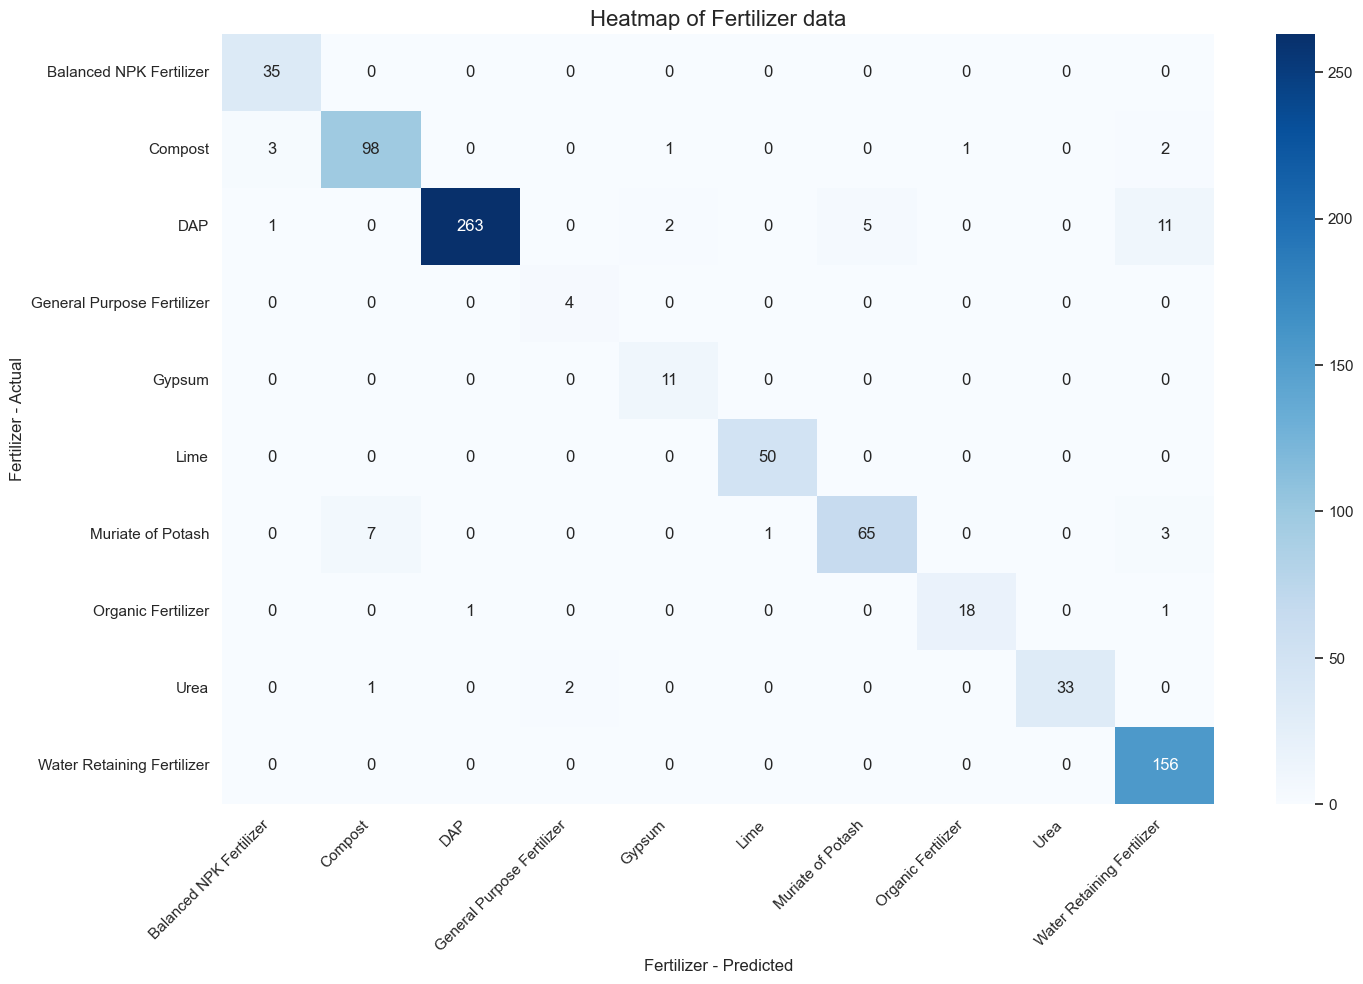

In [753]:

print(f"\nBest params: {rnd_search_rf_2.best_params_}")
print(f"Accuracy in CV: {rnd_search_rf_2.best_score_ * 100:.2f}%")

best_pipeline_model2_rf = rnd_search_rf_2.best_estimator_

y_pred_rf_fertilizer = best_pipeline_model2_rf.predict(X_test_fertilizer)
cm_rf_2 = confusion_matrix(y_test_fertilizer, y_pred_rf_fertilizer, labels=best_pipeline_model2_rf.classes_)
print_model_heatmap(best_pipeline_model2_rf, cm_rf_2, "Fertilizer")



### XGBoost


In [754]:
fertilizer_labels = LabelEncoder()
y_encoded_fertilizer = fertilizer_labels.fit_transform(fertilizer_column)

In [755]:
X_train_f_enc, X_test_f_enc, y_train_f_enc, y_test_f_enc = train_test_split(fertilizer_df_data, y_encoded_fertilizer, test_size=0.3, random_state=42, stratify=y_encoded_fertilizer)

print(X_train_f_enc)

      Temperature   Humidity    Rainfall  ...    Carbon          Soil         Crop
596     19.556307  59.977529   90.022418  ...  1.123491   Acidic Soil        maize
1166    17.181245  70.179426   54.172635  ...  1.139462    Loamy Soil         peas
3094    24.603762  74.191200  306.081601  ...  1.280331    Loamy Soil   watermelon
1991    53.557631  80.866944  306.081601  ...  0.945638   Acidic Soil  adzukibeans
1598    21.104372  56.709995  137.614555  ...  1.612144   Acidic Soil  kidneybeans
...           ...        ...         ...  ...       ...           ...          ...
3002    25.697766  58.519080   67.531679  ...  0.719457   Acidic Soil   watermelon
1177    50.179845  44.246772   58.587676  ...  0.681516  Neutral Soil         peas
1101    18.200360  60.851914   40.201132  ...  1.609834   Acidic Soil         peas
1666    29.144985  79.449694   52.890599  ...  0.842976   Acidic Soil    mothbeans
2656    30.167500  60.779886   24.391277  ...  1.151586   Acidic Soil    muskmelon

[21

In [756]:
categorical_columns, numerical_columns = cat_num(fertilizer_df_data)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

pipeline_xgb = Pipeline(steps=[
    ("preproc", preprocessor),
    ("classifier", XGBClassifier(random_state=42, eval_metric="mlogloss", n_jobs=-1))
])

param_grid_xgb = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "classifier__max_depth": [3, 5, 7, 9],
    "classifier__subsample": [0.8, 0.9, 1.0]
}


In [757]:
rnd_search_xgb_2 = build_model_with_classifier(pipeline_xgb, param_grid_xgb, X_train_f_enc, y_train_f_enc)

print(f"\nBest params: {rnd_search_xgb_2.best_params_}")
print(f"Accuracy in CV: {rnd_search_xgb_2.best_score_ * 100:.2f}%")

best_pipeline_model2 = rnd_search_xgb_2.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params: {'classifier__subsample': 0.8, 'classifier__n_estimators': 100, 'classifier__max_depth': 5, 'classifier__learning_rate': 0.2}
Accuracy in CV: 98.06%


# Interfaccia Web

In [758]:
import joblib


joblib.dump(best_model1, "model_1.pkl")

joblib.dump(best_pipeline_model2, "model_2.pkl")

joblib.dump(fertilizer_labels, "fertilizer_label_encoder.pkl") # Serve farlo nel caso in cui il modello sia xgboost

['fertilizer_label_encoder.pkl']